In [1]:
import sys
sys.path.insert(0,"..")

In [2]:
from src.data.fetch import fetch_stock_data,fetch_multiple

C:\Users\devgi\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df=fetch_stock_data("RELIANCE.NS",period="1y")
print(df.head())
print(df.tail())
print(df.describe())

Fetching RELIANCE.NS  (1y)...
Downloaded 250 trading days
Range : 2025-07-03 -> 2026-07-03
Latest Close : ₹1,304.00
Saved to C:\Users\devgi\InvestIQ\notebooks\..\data\raw\RELIANCE_NS_1y.csv
                   Open         High          Low        Close    Volume
Date                                                                    
2025-07-03  1507.778879  1518.783816  1500.045615  1504.804565  11283291
2025-07-04  1510.951595  1516.900223  1504.209768  1514.223389   6603501
2025-07-07  1513.529186  1531.573429  1511.942909  1528.301636   7251074
2025-07-08  1522.848782  1531.672604  1517.098393  1524.435059   7171261
2025-07-09  1523.542666  1537.720277  1497.170441  1505.994263   8870660
                   Open         High          Low        Close    Volume
Date                                                                    
2026-06-29  1308.000000  1313.699951  1292.599976  1301.000000  13757656
2026-06-30  1306.900024  1306.900024  1290.000000  1293.900024  15695263
2026-07

In [4]:
df["Return"]=(df["Close"]-df["Close"].shift(1))/df["Close"].shift(1)*100
# pct_change() = (today - yesterday) / yesterday — same as our formula earlier

In [5]:
# Was it a green day or red day?
df["Direction"]=df["Return"].apply(lambda r : "up" if r>0 else "down")


In [6]:
# What fraction of days were green?
green_days = (df["Direction"] == "up").sum()
total_days = len(df)
print(f"\nGreen days: {green_days}/{total_days} = {green_days/total_days:.1%}")



Green days: 117/250 = 46.8%


In [7]:
worst_day=df["Return"].idxmin()# date of minimum return
print(f"\nWorst Day: {worst_day.date()},Return: {df.loc[worst_day,'Return']:.2f}%")


Worst Day: 2026-03-27,Return: -4.60%


In [8]:
# Biggest single-day rally
best_day = df["Return"].idxmax()
print(f"Best day:  {best_day.date()}, Return: {df.loc[best_day, 'Return']:.2f}%")

Best day:  2025-10-20, Return: 3.53%


In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


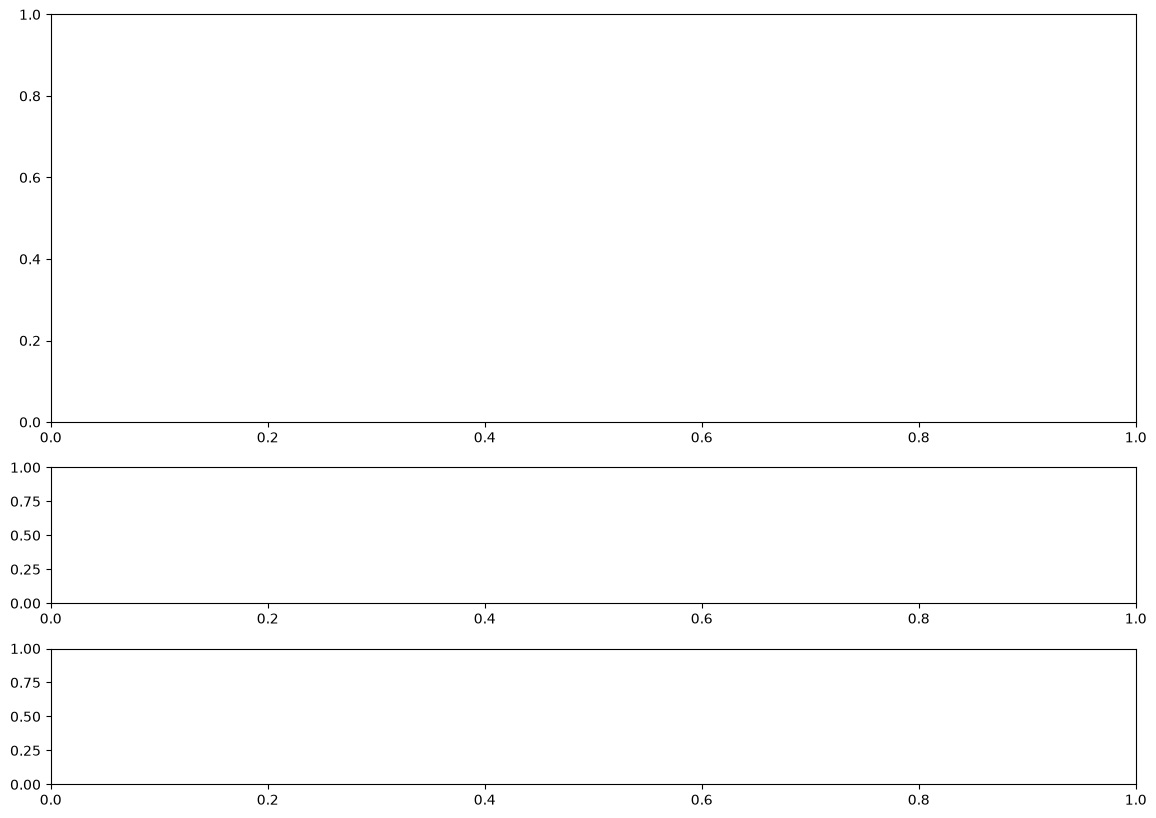

In [10]:

fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                          gridspec_kw={"height_ratios": [3, 1, 1]})



In [11]:
ax1 = axes[0]
ax1.plot(df.index, df["Close"], color="#1565C0", linewidth=1.2)
ax1.set_title("Reliance Industries — 1 Year", fontsize=13, pad=10)
ax1.set_ylabel("Price (₹)")
ax1.grid(axis="y", alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

In [12]:
# ── Panel 2: Volume bars ───────────────────────────────────────────
ax2 = axes[1]
# Colour each bar green/red based on price direction
colours = ["#43A047" if r > 0 else "#E53935" for r in df["Return"]]
ax2.bar(df.index, df["Volume"] / 1e6, color=colours, alpha=0.7, width=1)
ax2.set_ylabel("Volume (M)")
ax2.grid(axis="y", alpha=0.3)


In [13]:
# ── Panel 3: Daily return ──────────────────────────────────────────
ax3 = axes[2]
ax3.fill_between(df.index, df["Return"], 0,
                  where=(df["Return"] >= 0), color="#43A047", alpha=0.6)
ax3.fill_between(df.index, df["Return"], 0,
                  where=(df["Return"] < 0),  color="#E53935", alpha=0.6)
ax3.axhline(0, color="gray", linewidth=0.8)
ax3.set_ylabel("Daily Return (%)")
ax3.grid(axis="y", alpha=0.3)

In [14]:
fig.tight_layout()
fig.savefig("../data/charts/reliance_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

Chart saved.


COMPARING DIFFERENT STOCKS

In [15]:
NIFTY50_SAMPLE = ["RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS", "WIPRO.NS"]

stocks = fetch_multiple(NIFTY50_SAMPLE, period="1y")

Fetching RELIANCE.NS  (1y)...
Downloaded 250 trading days
Range : 2025-07-03 -> 2026-07-03
Latest Close : ₹1,304.00
Saved to C:\Users\devgi\InvestIQ\notebooks\..\data\raw\RELIANCE_NS_1y.csv
Fetching TCS.NS  (1y)...
Downloaded 250 trading days
Range : 2025-07-03 -> 2026-07-03
Latest Close : ₹2,093.50
Saved to C:\Users\devgi\InvestIQ\notebooks\..\data\raw\TCS_NS_1y.csv
Fetching INFY.NS  (1y)...
Downloaded 250 trading days
Range : 2025-07-03 -> 2026-07-03
Latest Close : ₹1,047.20
Saved to C:\Users\devgi\InvestIQ\notebooks\..\data\raw\INFY_NS_1y.csv
Fetching HDFCBANK.NS  (1y)...
Downloaded 250 trading days
Range : 2025-07-03 -> 2026-07-03
Latest Close : ₹801.05
Saved to C:\Users\devgi\InvestIQ\notebooks\..\data\raw\HDFCBANK_NS_1y.csv
Fetching WIPRO.NS  (1y)...
Downloaded 250 trading days
Range : 2025-07-03 -> 2026-07-03
Latest Close : ₹176.08
Saved to C:\Users\devgi\InvestIQ\notebooks\..\data\raw\WIPRO_NS_1y.csv

 Successfully downloaded 5/5 stocks


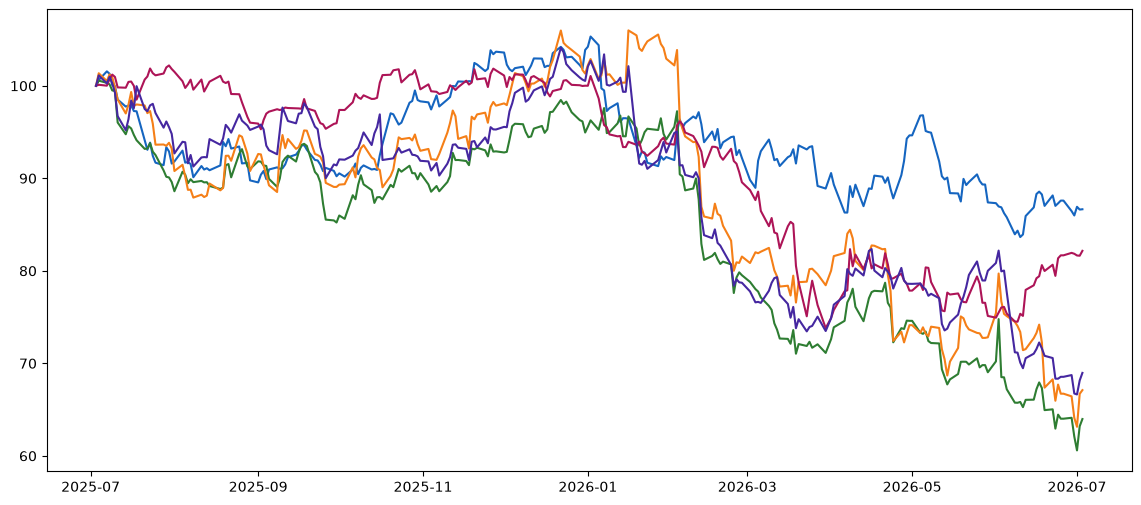

In [16]:
# ── Normalise each stock to start at 100 ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

colours = ["#1565C0", "#2E7D32", "#F57F17", "#AD1457", "#4527A0"]

for (ticker, df), colour in zip(stocks.items(), colours):
    # Divide every price by the FIRST price, then multiply by 100
    # Day 1 is always 100. Day 30 being 108 means +8% since start.
    normalised = (df["Close"] / df["Close"].iloc[0]) * 100

    # Clean up the ticker name for the legend label
    label = ticker.replace(".NS", "")

    ax.plot(df.index, normalised, label=label, color=colour, linewidth=1.5)


In [17]:
ax.axhline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.set_title("NIFTY50 Sample — Normalised Performance (Base = 100)", fontsize=13)
ax.set_ylabel("Relative Performance")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

In [18]:
fig.tight_layout()
fig.savefig("../data/comparison_chart.png", dpi=150)
plt.show()